In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from utils import to_snake_case

In [77]:
sales = pd.read_csv('../datasets/retail_sales_dataset.csv', parse_dates=['Date'])

In [78]:
column_names = to_snake_case(sales.columns.values.tolist())
sales.rename(columns=column_names, inplace=True)

sales[['gender', 'product_category']] = sales[['gender', 'product_category']].astype(dtype='category')

unique_customers = sales.loc[:200, 'customer_id'] # 199 customers
sales['customer_id'] = np.random.choice(unique_customers, size=len(sales), replace=True)

sales.head()

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount
0,1,2023-11-24,CUST148,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST052,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST190,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST187,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST033,Male,30,Beauty,2,50,100


In [79]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    1000 non-null   int64         
 1   date              1000 non-null   datetime64[ns]
 2   customer_id       1000 non-null   object        
 3   gender            1000 non-null   category      
 4   age               1000 non-null   int64         
 5   product_category  1000 non-null   category      
 6   quantity          1000 non-null   int64         
 7   price_per_unit    1000 non-null   int64         
 8   total_amount      1000 non-null   int64         
dtypes: category(2), datetime64[ns](1), int64(5), object(1)
memory usage: 57.0+ KB


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

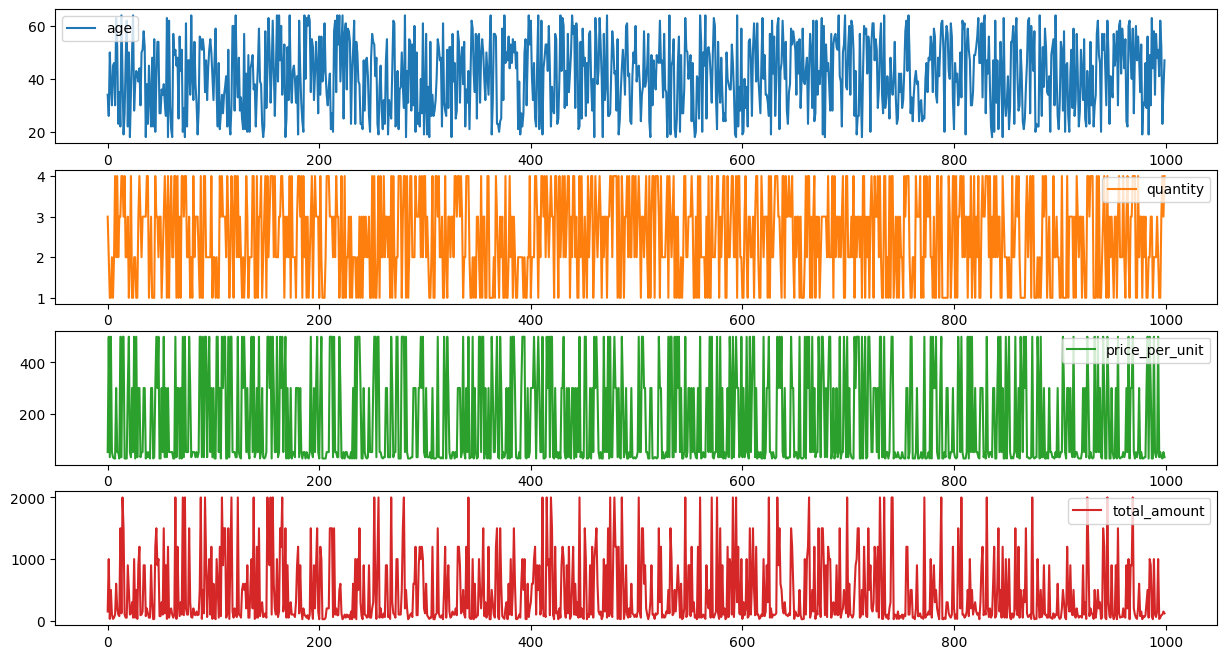

In [47]:
sales.drop('transaction_id', axis=1).plot(subplots=True, sharex=False, figsize=(15, 8))

1. Count the number of unique customers

In [48]:
sales['customer_id'].nunique()

199

2. List all unique product categories

In [49]:
sales['product_category'].unique()

['Beauty', 'Clothing', 'Electronics']
Categories (3, object): ['Beauty', 'Clothing', 'Electronics']

3. Find all transactions with Total Amount > 100 and Male and Beauty products

In [61]:
sales.loc[(sales['total_amount']>100) & (sales['gender'].str.lower()=='male') & (sales['product_category']=='Beauty')]

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount
0,1,2023-11-24,CUST049,Male,34,Beauty,3,50,150
35,36,2023-06-24,CUST112,Male,52,Beauty,3,300,900
37,38,2023-03-21,CUST076,Male,38,Beauty,4,50,200
54,55,2023-10-10,CUST142,Male,31,Beauty,4,30,120
59,60,2023-10-23,CUST150,Male,30,Beauty,3,50,150
...,...,...,...,...,...,...,...,...,...
930,931,2023-09-02,CUST183,Male,30,Beauty,4,30,120
933,934,2023-07-25,CUST181,Male,30,Beauty,1,500,500
935,936,2023-02-07,CUST067,Male,57,Beauty,4,50,200
946,947,2023-03-02,CUST148,Male,50,Beauty,1,300,300


In [60]:
sales.query("total_amount>100 and gender=='Male' and product_category=='Beauty'")

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount
0,1,2023-11-24,CUST049,Male,34,Beauty,3,50,150
35,36,2023-06-24,CUST112,Male,52,Beauty,3,300,900
37,38,2023-03-21,CUST076,Male,38,Beauty,4,50,200
54,55,2023-10-10,CUST142,Male,31,Beauty,4,30,120
59,60,2023-10-23,CUST150,Male,30,Beauty,3,50,150
...,...,...,...,...,...,...,...,...,...
930,931,2023-09-02,CUST183,Male,30,Beauty,4,30,120
933,934,2023-07-25,CUST181,Male,30,Beauty,1,500,500
935,936,2023-02-07,CUST067,Male,57,Beauty,4,50,200
946,947,2023-03-02,CUST148,Male,50,Beauty,1,300,300


4. Find transactions where age is between 30 and 40

In [62]:
sales.loc[sales['age'].between(30, 40)]

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount
0,1,2023-11-24,CUST049,Male,34,Beauty,3,50,150
3,4,2023-05-21,CUST019,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST184,Male,30,Beauty,2,50,100
7,8,2023-02-22,CUST001,Male,30,Electronics,4,25,100
11,12,2023-10-30,CUST066,Male,35,Beauty,3,25,75
...,...,...,...,...,...,...,...,...,...
979,980,2023-07-29,CUST191,Female,31,Electronics,3,25,75
980,981,2023-08-19,CUST154,Female,30,Electronics,2,30,60
986,987,2023-04-29,CUST055,Female,30,Clothing,3,300,900
990,991,2023-12-26,CUST147,Female,34,Clothing,2,50,100


5. Calculate total revenue for each product category

In [67]:
sales.groupby(['product_category']).agg(total_revenue=('total_amount', 'sum')).reset_index()

C:\Users\rah\AppData\Local\Temp\ipykernel_2736\4006740366.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales.groupby(['product_category']).agg(total_revenue=('total_amount', 'sum')).reset_index()


,product_category,total_revenue
0,Beauty,143515
1,Clothing,155580
2,Electronics,156905


6. Find average age of customers by gender

In [72]:
sales.groupby(['gender']).agg(age_avg=('age', 'mean'), age_std=('age', 'std')).reset_index()

C:\Users\rah\AppData\Local\Temp\ipykernel_2736\3996844675.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales.groupby(['gender']).agg(age_avg=('age', 'mean'), age_std=('age', 'std')).reset_index()


,gender,age_avg,age_std
0,Female,41.356863,13.568067
1,Male,41.428571,13.812208


7. Find the most expensive transaction (max Total Amount)

In [71]:
max_total_amount = sales['total_amount']
sales.loc[sales['total_amount']==max(max_total_amount)]

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount
14,15,2023-01-16,CUST197,Female,42,Electronics,4,500,2000
64,65,2023-12-05,CUST158,Male,51,Electronics,4,500,2000
71,72,2023-05-23,CUST171,Female,20,Electronics,4,500,2000
73,74,2023-11-22,CUST055,Female,18,Beauty,4,500,2000
88,89,2023-10-01,CUST113,Female,55,Electronics,4,500,2000
92,93,2023-07-14,CUST114,Female,35,Beauty,4,500,2000
108,109,2023-10-18,CUST003,Female,34,Electronics,4,500,2000
117,118,2023-05-16,CUST192,Female,30,Electronics,4,500,2000
123,124,2023-10-27,CUST138,Male,33,Clothing,4,500,2000
138,139,2023-12-15,CUST024,Male,36,Beauty,4,500,2000


8. Calculate average quantity purchased per category

In [74]:
sales.groupby(['product_category']).agg(qty_avg=('age', 'mean')).reset_index()

C:\Users\rah\AppData\Local\Temp\ipykernel_2736\3331518259.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales.groupby(['product_category']).agg(qty_avg=('age', 'mean')).reset_index()


,product_category,qty_avg
0,Beauty,40.371336
1,Clothing,41.948718
2,Electronics,41.736842


10. Find total revenue by gender and category

In [94]:
sales.groupby(['product_category', 'gender']).agg(total_revenue=('total_amount', 'sum')).reset_index()

C:\Users\rah\AppData\Local\Temp\ipykernel_2736\3843283990.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales.groupby(['product_category', 'gender']).agg(total_revenue=('total_amount', 'sum')).reset_index()


,product_category,gender,total_revenue
0,Beauty,Female,74830
1,Beauty,Male,68685
2,Clothing,Female,81275
3,Clothing,Male,74305
4,Electronics,Female,76735
5,Electronics,Male,80170


11. Create a 'Month', 'Quarter', 'Year' column from the Date

In [84]:
sales['year'] = sales['date'].dt.year
sales['quarter'] = sales['date'].dt.quarter
sales['month'] = sales['date'].dt.month
sales.head()

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount,year,quarter,month
0,1,2023-11-24,CUST148,Male,34,Beauty,3,50,150,2023,4,11
1,2,2023-02-27,CUST052,Female,26,Clothing,2,500,1000,2023,1,2
2,3,2023-01-13,CUST190,Male,50,Electronics,1,30,30,2023,1,1
3,4,2023-05-21,CUST187,Male,37,Clothing,1,500,500,2023,2,5
4,5,2023-05-06,CUST033,Male,30,Beauty,2,50,100,2023,2,5


12. Create a 'Customer Segment' column based on age:
   - 'Young': < 30
   - 'Middle': 30-45
   - 'Senior': > 45

In [85]:
sales['age_segment'] = np.where(sales['age']<30, 'young', np.where(sales['age'].between(30, 45), 'middle', 'senior'))

In [88]:
sales.head()

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount,year,quarter,month,age_segment
0,1,2023-11-24,CUST148,Male,34,Beauty,3,50,150,2023,4,11,middle
1,2,2023-02-27,CUST052,Female,26,Clothing,2,500,1000,2023,1,2,young
2,3,2023-01-13,CUST190,Male,50,Electronics,1,30,30,2023,1,1,senior
3,4,2023-05-21,CUST187,Male,37,Clothing,1,500,500,2023,2,5,middle
4,5,2023-05-06,CUST033,Male,30,Beauty,2,50,100,2023,2,5,middle


13. Create a 'Discount' column (10% for orders > 500)

In [93]:
sales['discount'] = np.where(sales['total_amount']>500, sales['total_amount']*0.1, 0)
sales.head()

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount,year,quarter,month,age_segment,discount
0,1,2023-11-24,CUST148,Male,34,Beauty,3,50,150,2023,4,11,middle,0.0
1,2,2023-02-27,CUST052,Female,26,Clothing,2,500,1000,2023,1,2,young,100.0
2,3,2023-01-13,CUST190,Male,50,Electronics,1,30,30,2023,1,1,senior,0.0
3,4,2023-05-21,CUST187,Male,37,Clothing,1,500,500,2023,2,5,middle,0.0
4,5,2023-05-06,CUST033,Male,30,Beauty,2,50,100,2023,2,5,middle,0.0


14. For each product category, find:
   - Total revenue
   - Average transaction value
   - Total quantity sold

In [104]:
sales.groupby(['product_category'], observed=True).agg(
    total_revenue=('total_amount', 'sum'),
    avg_revenue=('total_amount', 'mean'),
    quantity=('quantity', 'sum')
).round(2).reset_index()

,product_category,total_revenue,avg_revenue,quantity
0,Beauty,143515,467.48,771
1,Clothing,155580,443.25,894
2,Electronics,156905,458.79,849


14. Find the most popular product category

In [103]:
sales['product_category'].value_counts()

product_category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

15. Find the top 5 customers with the highest total spend

In [108]:
sales.groupby(['customer_id'], observed=True).agg(
    total_revenue=('total_amount', 'sum')
).reset_index().sort_values(by='total_revenue', ascending=False).head()

,customer_id,total_revenue
8,CUST009,7075
179,CUST183,6675
141,CUST144,6590
189,CUST193,6590
174,CUST178,6205


16. Calculate cumulative revenue over time + chart

In [126]:
sales_year_month = sales.groupby(['year', 'quarter', 'month']).agg(
    total_revenue=('total_amount', 'sum')
).reset_index()

sales_year_month['running_total'] = sales_year_month.groupby(['year', 'quarter'])['total_revenue'].transform('cumsum')
sales_year_month

,year,quarter,month,total_revenue,running_total
0,2023,1,1,35450,35450
1,2023,1,2,44060,79510
2,2023,1,3,28990,108500
3,2023,2,4,33870,33870
4,2023,2,5,53150,87020
5,2023,2,6,36715,123735
6,2023,3,7,35465,35465
7,2023,3,8,36960,72425
8,2023,3,9,23620,96045
9,2023,4,10,46580,46580


<Axes: >

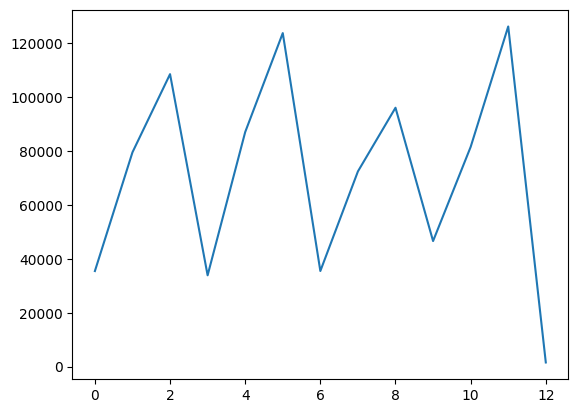

In [127]:
sales_year_month['running_total'].plot()

17. Find average revenue over time

<Axes: xlabel='year,month'>

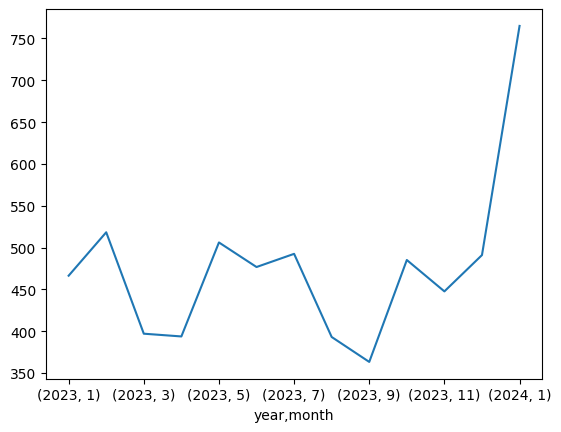

In [136]:
daily_avg_revenue = sales.groupby(['year', 'month'])['total_amount'].mean()
daily_avg_revenue.plot()

18. Outlier detection (IQR)

In [137]:
Q1 = sales['total_amount'].quantile(0.25)
Q3 = sales['total_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
sales[(sales['total_amount'] < lower_bound) | (sales['total_amount'] > upper_bound)]

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount,year,quarter,month,age_segment,discount


19. Find customers who are repeat customers

In [140]:
repeat_customers = sales['customer_id'].value_counts()
repeat_customers[repeat_customers > 1]

customer_id
CUST180    12
CUST104    10
CUST191    10
CUST065    10
CUST112    10
           ..
CUST129     2
CUST037     2
CUST192     2
CUST158     2
CUST194     2
Name: count, Length: 188, dtype: int64

20. Create correlation matrix for numerical columns

In [145]:
sales.drop(['transaction_id', 'discount'], axis=1).select_dtypes(np.number).corr()

,age,quantity,price_per_unit,total_amount,year,quarter,month
age,1.000000,-0.023737,-0.038423,-0.060568,0.023269,-0.000837,-0.000640
quantity,-0.023737,1.000000,0.017501,0.373707,-0.020324,-0.020411,-0.021803
price_per_unit,-0.038423,0.017501,1.000000,0.851925,0.020097,-0.005834,-0.008161
total_amount,-0.060568,0.373707,0.851925,1.000000,0.024714,-0.001605,-0.005197
year,0.023269,-0.020324,0.020097,0.024714,1.000000,-0.061028,-0.071981
quarter,-0.000837,-0.020411,-0.005834,-0.001605,-0.061028,1.000000,0.972875
month,-0.000640,-0.021803,-0.008161,-0.005197,-0.071981,0.972875,1.000000
